In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [35]:
df = pd.read_csv('data_gurgaon_properties_missing_value_imputation.csv')

In [36]:
pd.set_option('display.max_columns', None)

In [37]:
df

,property_name,type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,address,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,3 BHK Flat in Sector 65 Gurgaon,flat,m3m golfestate,sector 65,4.94,16234.0,3,4,3,"Tower, Sector 65 Gurgaon, Gurgaon, Haryana",15.0,Moderately Old,"M3m golfestate in sector 65, gurgaon is a read...",2754.0,0,1,0,0,0,1,165
1,3 BHK Flat in Palam Vihar,flat,bestech park view residency,sector 2,1.55,8073.0,3,4,3,"Palam Vihar, Gurgaon, Haryana",10.0,Moderately Old,Bestech park view residency is one of the most...,1738.0,0,1,0,0,0,1,100
2,3 BHK Flat in Sector 90 Gurgaon,flat,dlf regal gardens,sector 90,1.25,8117.0,3,3,3,"101, Sector 90 Gurgaon, Gurgaon, Haryana",8.0,Relatively New,This 3 bhk flat is located in dlf regal garden...,1640.0,0,0,0,1,0,1,158
3,2 BHK Flat in Sector 36 Gurgaon,flat,signature global infinity mall,sector 36,0.41,6269.0,2,2,3,"Sohna Sector 36, Sector 36 Gurgaon, Gurgaon, H...",3.0,New Property,Best in class property available at sector 36 ...,654.0,0,0,0,0,0,1,0
4,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.20,9677.0,2,2,3,"Tower 1, Sector 85 Gurgaon, Gurgaon, Haryana",9.0,Relatively New,Looking for a 2 bhk property for sale in gurga...,1491.0,0,0,1,0,0,1,148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,3 BHK Flat in Sector 104 Gurgaon,flat,godrej summit,sector 104,1.05,5833.0,3,4,3,"Sector 104 Gurgaon, Gurgaon, Haryana",7.0,Relatively New,Godrej summit society is resort like society h...,2000.0,0,1,0,0,0,0,96
3494,5 Bedroom House for sale in Sector 28 Gurgaon,house,suncity essel towers,sector 28,8.95,17888.0,5,6,3,"Sector 28 Gurgaon, Gurgaon, Haryana",4.0,Moderately Old,"East entry vastu perfect\nLot of daylight, no ...",5000.0,0,0,0,0,0,1,0
3495,4 BHK Flat in Sector 81 Gurgaon,flat,bestech park view grand spa,sector 81,4.70,6786.0,4,4,3,"1908, Sector 81 Gurgaon, Gurgaon, Haryana",19.0,Relatively New,Semi furnished 4bhk 6926sqft penthouse with pe...,6268.0,0,1,0,0,0,0,140
3496,3 BHK Flat in Sector 103 Gurgaon,flat,spire woods now ananda by alpha corp,sector 103,1.25,6902.0,3,4,3,"Sector 103 Gurgaon, Gurgaon, Haryana",11.0,Under Construction,Spire woods now ananda by alpha corp in sector...,2012.0,1,1,0,0,0,1,105


In [38]:
df.drop(['property_name', 'society', 'address', 'description'], axis=1, inplace=True)

In [39]:
df

,type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 65,4.94,16234.0,3,4,3,15.0,Moderately Old,2754.0,0,1,0,0,0,1,165
1,flat,sector 2,1.55,8073.0,3,4,3,10.0,Moderately Old,1738.0,0,1,0,0,0,1,100
2,flat,sector 90,1.25,8117.0,3,3,3,8.0,Relatively New,1640.0,0,0,0,1,0,1,158
3,flat,sector 36,0.41,6269.0,2,2,3,3.0,New Property,654.0,0,0,0,0,0,1,0
4,flat,sector 85,1.20,9677.0,2,2,3,9.0,Relatively New,1491.0,0,0,1,0,0,1,148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,flat,sector 104,1.05,5833.0,3,4,3,7.0,Relatively New,2000.0,0,1,0,0,0,0,96
3494,house,sector 28,8.95,17888.0,5,6,3,4.0,Moderately Old,5000.0,0,0,0,0,0,1,0
3495,flat,sector 81,4.70,6786.0,4,4,3,19.0,Relatively New,6268.0,0,1,0,0,0,0,140
3496,flat,sector 103,1.25,6902.0,3,4,3,11.0,Under Construction,2012.0,1,1,0,0,0,1,105


In [40]:
# train_df = df.drop(['price', 'price_per_sqft'], axis=1)

<Axes: >

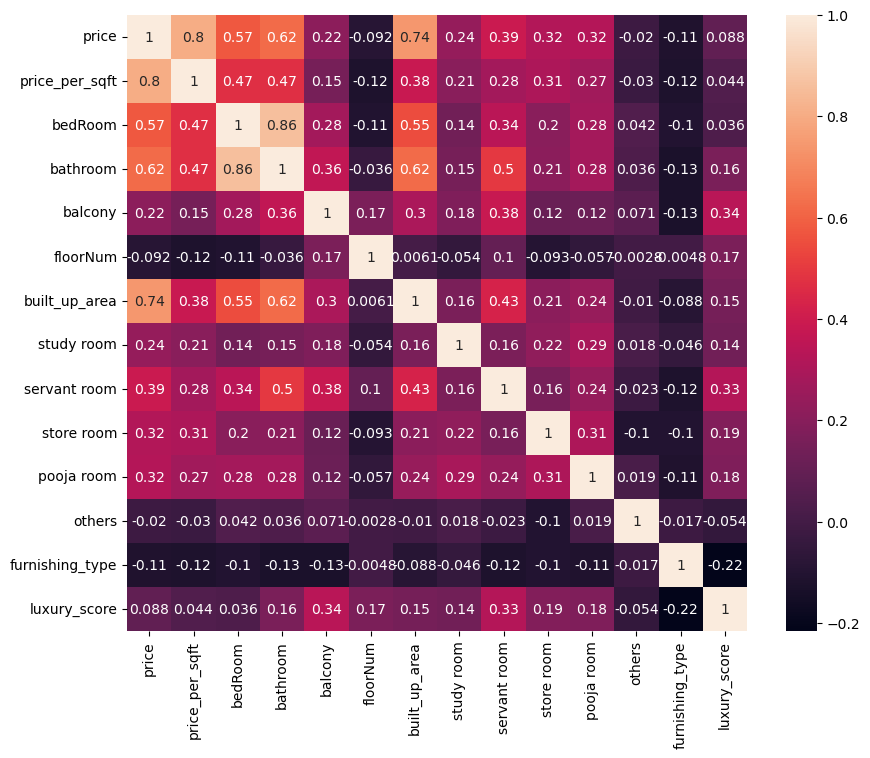

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(['type', 'sector', 'agePossession'], axis=1).corr(), annot=True)

<Axes: ylabel='luxury_score'>

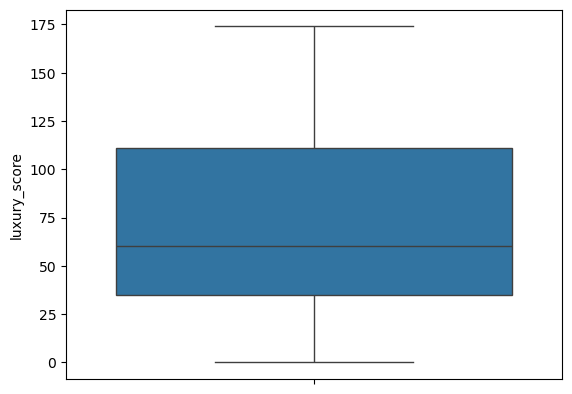

In [42]:
sns.boxplot(df['luxury_score'])

In [43]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins"

In [44]:
df['luxury_category'] = df['luxury_score'].apply(categorize_luxury)

<Axes: ylabel='floorNum'>

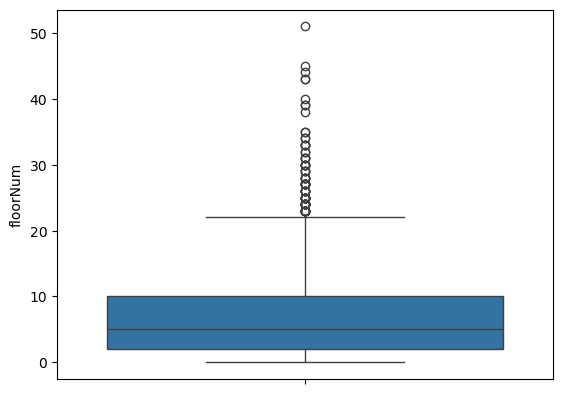

In [45]:
sns.boxplot(df['floorNum'])

In [46]:
def categorize_floor(floor):
    if 0 <= floor <= 3:
        return "Low Floor"
    elif 4 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  

In [47]:
df['floor_category'] = df['floorNum'].apply(categorize_floor)

In [48]:
df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [49]:
df.head()

,type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 65,4.94,16234.0,3,4,3,Moderately Old,2754.0,0,1,0,0,0,1,High,High Floor
1,flat,sector 2,1.55,8073.0,3,4,3,Moderately Old,1738.0,0,1,0,0,0,1,Medium,Mid Floor
2,flat,sector 90,1.25,8117.0,3,3,3,Relatively New,1640.0,0,0,0,1,0,1,High,Mid Floor
3,flat,sector 36,0.41,6269.0,2,2,3,New Property,654.0,0,0,0,0,0,1,Low,Low Floor
4,flat,sector 85,1.20,9677.0,2,2,3,Relatively New,1491.0,0,0,1,0,0,1,Medium,Mid Floor


In [50]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = df.drop(['price_per_sqft'], axis=1)
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop(['price'], axis=1)
y_label = df['price']

[array(['flat', 'house'], dtype=object)]
[array(['arjun nagar', 'bhondsi', 'devilal colony', 'dwarka expressway',
       'gwal pahari', 'manesar', 'ravi nagar', 'saraswati vihar',
       'sector 1', 'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 22', 'sector 23', 'sector 24', 'sector 25', 'sector 26',
       'sector 27', 'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50

<Axes: >

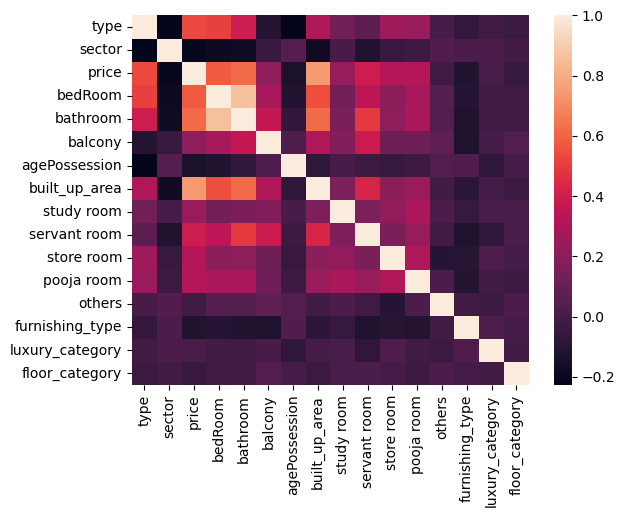

In [51]:
 sns.heatmap(data_label_encoded.corr())

In [83]:
fi_1 =data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index': 'feature', 'price': 'corr_coeff' })
fi_1

,feature,corr_coeff
0,sector,-0.211249
1,price,1.000000
2,bedRoom,0.574814
3,bathroom,0.620737
4,balcony,0.215170
5,agePossession,-0.139797
6,built_up_area,0.743026
7,study room,0.238054
8,servant room,0.391941
9,store room,0.317186


## Technique 2 - Random Forest Feature Importance

In [84]:
X_label

,type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,77.0,3,4,3,0.0,2754.0,0,1,0,0,0,1,0.0,0.0
1,0.0,30.0,3,4,3,0.0,1738.0,0,1,0,0,0,1,2.0,2.0
2,0.0,107.0,3,3,3,3.0,1640.0,0,0,0,1,0,1,0.0,2.0
3,0.0,44.0,2,2,3,1.0,654.0,0,0,0,0,0,1,1.0,1.0
4,0.0,101.0,2,2,3,3.0,1491.0,0,0,1,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,0.0,11.0,3,4,3,3.0,2000.0,0,1,0,0,0,0,2.0,2.0
3494,1.0,37.0,5,6,3,0.0,5000.0,0,0,0,0,0,1,1.0,2.0
3495,0.0,96.0,4,4,3,3.0,6268.0,0,1,0,0,0,0,2.0,0.0
3496,0.0,10.0,3,4,3,4.0,2012.0,1,1,0,0,0,1,2.0,0.0


In [85]:
from sklearn.ensemble import RandomForestRegressor

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# extracting the features 

fi_2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance' : rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

In [86]:
fi_2

,feature,rf_importance
6,built_up_area,0.648379
0,type,0.109157
1,sector,0.103349
3,bathroom,0.029106
2,bedRoom,0.020794
8,servant room,0.019345
5,agePossession,0.014562
12,furnishing_type,0.009404
13,luxury_category,0.008934
4,balcony,0.008362


In [87]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# extracting the features 

fi_3 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance' : gb_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_3

,feature,rf_importance
6,built_up_area,0.692503
0,type,0.105832
1,sector,0.099598
2,bedRoom,0.029555
3,bathroom,0.028673
8,servant room,0.022077
9,store room,0.008303
13,luxury_category,0.002750
4,balcony,0.002219
5,agePossession,0.001960


In [88]:
# Technique 4 - Permutation Importance
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_label_train , X_label_test, y_label_train, y_label_test = train_test_split(X_label, y_label, train_size=0.8, random_state=42)

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label_train, y_label_train)

permutation_imp = permutation_importance(rf_label, X_label_test, y_label_test, n_repeats=30, random_state=42)

fi_4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': permutation_imp.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_4

,feature,permutation_importance
6,built_up_area,0.685798
0,type,0.247462
1,sector,0.165103
8,servant room,0.020024
5,agePossession,0.008978
14,floor_category,0.005695
2,bedRoom,0.004218
12,furnishing_type,0.003705
3,bathroom,0.003319
4,balcony,0.001725


In [89]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_5

,feature,lasso_coeff
6,built_up_area,1.430855
0,type,0.778442
3,bathroom,0.405509
9,store room,0.199757
7,study room,0.165324
8,servant room,0.145408
10,pooja room,0.097982
13,luxury_category,0.038931
4,balcony,0.000000
11,others,-0.022232


In [90]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_6

,feature,rfe_score
6,built_up_area,0.653464
0,type,0.109634
1,sector,0.103342
3,bathroom,0.028170
2,bedRoom,0.018846
8,servant room,0.017456
5,agePossession,0.013032
12,furnishing_type,0.009403
13,luxury_category,0.008894
4,balcony,0.007914


In [91]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_7

,feature,reg_coeffs
6,built_up_area,1.432963
0,type,0.799434
3,bathroom,0.477712
9,store room,0.201212
7,study room,0.170861
8,servant room,0.141462
10,pooja room,0.104105
13,luxury_category,0.048661
4,balcony,0.006260
11,others,-0.030818


In [92]:
final_fi_ = fi_1.merge(fi_2,on='feature').merge(fi_3,on='feature').merge(fi_4,on='feature').merge(fi_5,on='feature').merge(fi_6,on='feature').merge(fi_7,on='feature').set_index('feature')

In [93]:
final_fi_

,corr_coeff,rf_importance_x,rf_importance_y,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
sector,-0.211249,0.103349,0.099598,0.165103,-0.054631,0.103342,-0.062444
bedRoom,0.574814,0.020794,0.029555,0.004218,-0.094900,0.018846,-0.184998
bathroom,0.620737,0.029106,0.028673,0.003319,0.405509,0.028170,0.477712
balcony,0.215170,0.008362,0.002219,0.001725,0.000000,0.007914,0.006260
agePossession,-0.139797,0.014562,0.001960,0.008978,-0.047677,0.013032,-0.056804
built_up_area,0.743026,0.648379,0.692503,0.685798,1.430855,0.653464,1.432963
study room,0.238054,0.006306,0.001871,0.000814,0.165324,0.006636,0.170861
servant room,0.391941,0.019345,0.022077,0.020024,0.145408,0.017456,0.141462
store room,0.317186,0.006514,0.008303,-0.001994,0.199757,0.007595,0.201212


In [99]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [100]:
scores.mean()

0.8282874537047403

In [96]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [97]:
scores.mean()

0.8296865935228503

In [101]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [102]:
export_df

,type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,77.0,3,4,3,0.0,2754.0,1,0,1,0.0,0.0,4.94
1,0.0,30.0,3,4,3,0.0,1738.0,1,0,1,2.0,2.0,1.55
2,0.0,107.0,3,3,3,3.0,1640.0,0,0,1,0.0,2.0,1.25
3,0.0,44.0,2,2,3,1.0,654.0,0,0,1,1.0,1.0,0.41
4,0.0,101.0,2,2,3,3.0,1491.0,0,1,1,2.0,2.0,1.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,0.0,11.0,3,4,3,3.0,2000.0,1,0,0,2.0,2.0,1.05
3494,1.0,37.0,5,6,3,0.0,5000.0,0,0,1,1.0,2.0,8.95
3495,0.0,96.0,4,4,3,3.0,6268.0,1,0,0,2.0,0.0,4.70
3496,0.0,10.0,3,4,3,4.0,2012.0,1,0,1,2.0,0.0,1.25


In [103]:
export_df.to_csv('data_gurgaon_properties_feature_selection_done.csv')